In [1]:
# Setup: clone the StarX repo and the pinned TripoSR commit, install this
# notebook's dependencies, mount Drive, and report what machine we are on.
import os
import subprocess
import sys

BRANCH = "main"
TRIPOSR_COMMIT = "107cefdc244c39106fa830359024f6a2f1c78871"
NOTEBOOK_ID = "05"

IN_COLAB = os.path.exists("/content")
if IN_COLAB:
    REPO_DIR, TRIPOSR_DIR = "/content/StarX", "/content/TripoSR"
    if not os.path.exists(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--branch", BRANCH,
             "https://github.com/SattamAltwaim/StarX.git", REPO_DIR],
            check=True,
        )
else:
    REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
    TRIPOSR_DIR = os.path.join(REPO_DIR, "third_party", "TripoSR")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

if not os.path.exists(TRIPOSR_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/VAST-AI-Research/TripoSR.git",
         TRIPOSR_DIR],
        check=True,
    )
subprocess.run(["git", "-C", TRIPOSR_DIR, "checkout", "-q", TRIPOSR_COMMIT], check=True)

from starx import pins

assert pins.TRIPOSR_COMMIT == TRIPOSR_COMMIT, "notebook pin out of sync with starx/pins.py"
if pins.PIP_PINS[NOTEBOOK_ID]:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pins.PIP_PINS[NOTEBOOK_ID]],
        check=True,
    )
# remove Colab preinstalls that break the pinned stack (see starx/pins.py)
if pins.PIP_UNINSTALL.get(NOTEBOOK_ID):
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-q", "-y",
         *pins.PIP_UNINSTALL[NOTEBOOK_ID]],
        check=False, capture_output=True,
    )

from starx import colab as scolab

DRIVE = scolab.mount_drive()
report = scolab.setup_report()

Mounted at /content/drive
        python: 3.12.13
         torch: 2.11.0+cu128
cuda_available: True
           gpu: Tesla T4
       vram_gb: 14.6
  disk_free_gb: 65.7
     cpu_count: 2
      in_colab: True


# 05 - Training

Everything meets here: the surgered model from notebook 04 learns to turn sketch stacks into 3D shapes, supervised purely by rendering - compare small rendered crops of its prediction against the ground-truth views from notebook 03.

One optimizer step: draw a few designs, encode each sketch stack into a triplane scene code (in the GPU's fast half precision), render a couple of crops per design at ground-truth cameras (in full precision), score them with three loss terms, backpropagate in two stages, clip, update. Only the LoRA adapters and the new patch embedding move; 99% of the model stays frozen.

Requirements: the shards from notebook 03 (with the same SMOKE setting) and a GPU runtime. **Pick an L4 or A100 in Runtime > Change runtime type** - a step takes about a second there, versus tens of seconds on a T4 (no hardware bf16). Set SMOKE to overfit a tiny set first: if the loss does not collapse there, something is wrong and the full run would waste hours.

In [ ]:
# Configuration - every tunable for this notebook lives here.
import time
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from starx import cameras, checkpoint, data, shards, viz
from starx import model as smodel
from starx import train as strain
from starx.config import FOVY_DEG, StarXConfig, run_dir, shard_dir

SMOKE = False    # True: overfit the 20-design smoke shards as a sanity run
RUN_NAME = "smoke_overfit" if SMOKE else "baseline_l4"
RESUME = True    # False: ignore existing checkpoints for this run name
SEED = 1337
SPLIT_PREFIX = "smoke_" if SMOKE else ""

cfg = StarXConfig(
    drive_root=str(DRIVE / "StarX")
    if DRIVE is not None
    else os.path.join(REPO_DIR, "data", "StarX"),
    local_root="/content/starx_local"
    if IN_COLAB
    else os.path.join(REPO_DIR, "data", "local"),
    # surgery - must match notebook 04
    max_sketch_channels=6,
    conv_init="i3d_mean",
    lora_r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    dino_layers=(0, 1, 2, 3),
    train_triplane_embed=False,
    # training
    total_steps=1000 if SMOKE else 20000,
    lr=1e-4,
    warmup_steps=100 if SMOKE else 500,
    accum_designs=4 if SMOKE else 8,
    views_per_design=2,
    render_crop=128,
    lambda_mse=1.0,
    lambda_lpips=2.0,
    lambda_mask=0.05,
    lambda_occ=0.5,   # 3D visual-hull soft-Dice term (0 disables)
    hull_res=48,      # occupancy grid resolution for the 3D term
    grad_clip=1.0,
    ckpt_every=250 if SMOKE else 500,
    keep_k=3,
    val_every=200 if SMOKE else 1000,
    gt_size=256,
    eval_chunk=131072,
    seed=SEED,
)
device = "cuda" if torch.cuda.is_available() else "cpu"

# precision, matched to the GPU: bf16 has hardware support on Ampere and
# newer (L4, A100); on a T4 or V100 it is missing, so fp16 is used there,
# with gradient scaling to avoid underflow.
AMP_DTYPE, GRAD_SCALE = strain.pick_amp(device)

print(
    f"run {RUN_NAME}: {cfg.total_steps} steps, "
    f"{cfg.accum_designs} designs x {cfg.views_per_design} views per step, "
    f"crop {cfg.render_crop}, lambda_occ {cfg.lambda_occ}, device {device}"
)
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}   autocast dtype: {AMP_DTYPE}")
    if AMP_DTYPE is torch.float16:
        print("NOTE: this GPU has no fast bf16 - training works but is "
              "slower; prefer an L4/A100")

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

train designs: 6897   validation designs: 1725


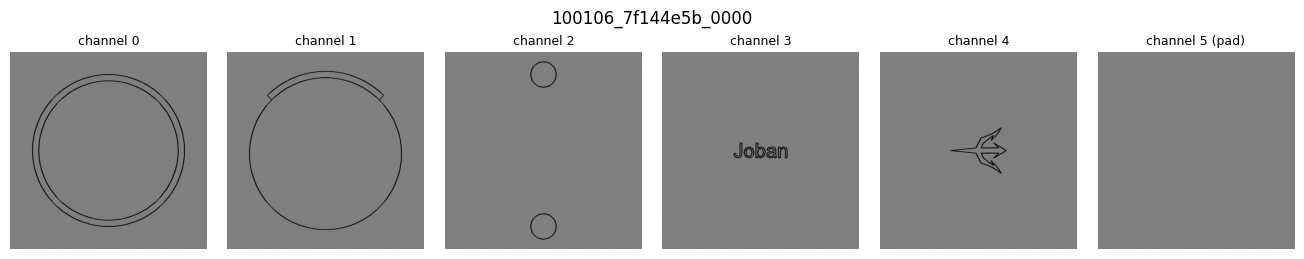

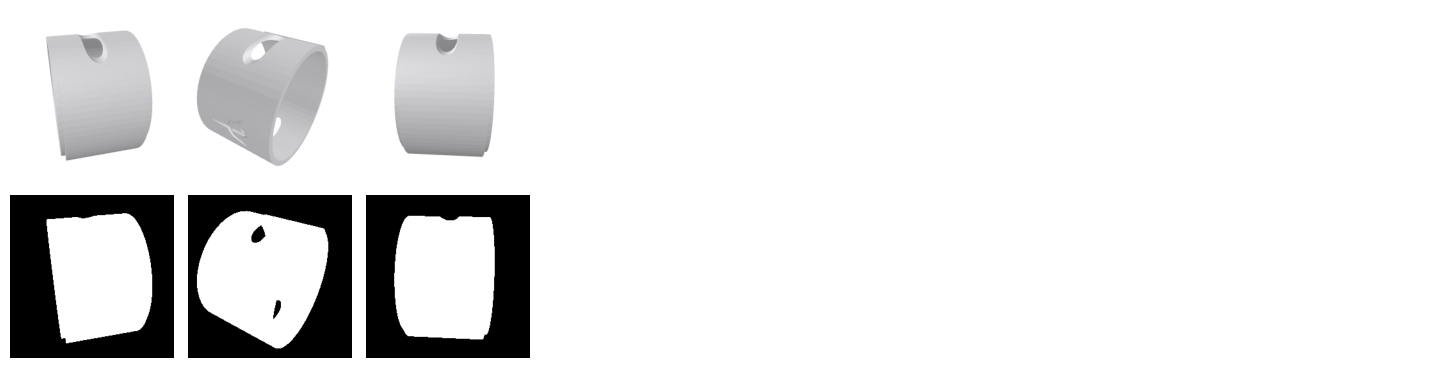

In [3]:
# Copy the shards from Drive to fast local disk (once per session), open
# the datasets, and browse one item end to end.
train_remote = shard_dir(cfg, f"{SPLIT_PREFIX}train")
val_remote = shard_dir(cfg, f"{SPLIT_PREFIX}test")
train_local = Path(cfg.local_root) / f"{SPLIT_PREFIX}train"
val_local = Path(cfg.local_root) / f"{SPLIT_PREFIX}test"
shards.prepare_local(train_remote, train_local, progress=tqdm)
shards.prepare_local(val_remote, val_local, progress=tqdm)

train_dataset = data.DesignDataset(train_local / "cache")
val_dataset = data.DesignDataset(val_local / "cache")
assert len(train_dataset) > 0, "no train shards found - run notebook 03 first (matching SMOKE)"
if len(val_dataset) == 0:
    val_dataset = train_dataset
    print("no test shards - using train designs for validation visuals")
print(f"train designs: {len(train_dataset)}   validation designs: {len(val_dataset)}")

browse = train_dataset[0]
fig = viz.show_sketch_stack(browse["stack_uint8"], browse["meta"], title=browse["design_id"])
plt.show()
fig = viz.show_view_grid(list(browse["views"][:3]), list(browse["masks"][:3]))
plt.show()

In [4]:
# Build the surgered model exactly as notebook 04 verified it, then turn
# on gradient checkpointing (recompute activations during backward instead
# of storing them) and disable render chunking - under autograd the memory
# lever is crop size, not chunking.
model, build_info = smodel.build_starx_model(cfg, TRIPOSR_DIR, device=device)
model.image_tokenizer.model.gradient_checkpointing_enable()
model.backbone.gradient_checkpointing = True
model.renderer.set_chunk_size(0)

trainable_params = [p for p in model.parameters() if p.requires_grad]
totals = build_info["param_table"]["ALL"]
print(f"trainable: {totals['trainable']:,} of {totals['total']:,} "
      f"({100 * totals['trainable'] / totals['total']:.2f}%)")
print("lora modules:", build_info["lora_counts"])

config.yaml:   0%|          | 0.00/987 [00:00<?, ?B/s]

model.ckpt: reconstructing file:   0%|          |  0.00B / 1.68GB            

model.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

trainable: 5,538,560 of 424,223,596 (1.31%)
lora modules: {'dino_lora_modules': 12, 'backbone_lora_modules': 128}


In [ ]:
# Optimizer and schedule from starx.train (shared with the script):
# AdamW with no weight decay on LoRA and a little on the new conv, linear
# warmup into cosine decay - plus the frozen VGG that scores the
# perceptual loss.
from torchmetrics.image import LearnedPerceptualImagePatchSimilarity

optimizer, scheduler = strain.build_optimizer(model, trainable_params, cfg)

lpips_metric = LearnedPerceptualImagePatchSimilarity(net_type="vgg", normalize=True)
lpips_metric = lpips_metric.to(device).requires_grad_(False)
lpips_metric.eval()
group_sizes = [sum(p.numel() for p in g["params"]) for g in optimizer.param_groups]
print(f"param groups (lora, conv): {group_sizes[0]:,} / {group_sizes[1]:,}")

## The render path, and a two-stage backward

TripoSR ships a render method, but it is wrapped in no-gradient mode and composites over white without exposing opacity - unusable for training, where gradients must flow and the mask loss needs opacity. So the next cell writes the ray march ourselves from the renderer's building blocks. It is the one place the volume-rendering math is fully visible.

Memory is dominated by rendering, not by the transformer: one small crop already queries the NeRF at about two million points, and that graph is the VRAM peak. The training step therefore handles views one at a time - render a view, backpropagate its loss only as far as the scene code, free the render graph, next view - and only when a design's views are done does the collected scene-code gradient flow through the big encoder, once. Same gradients as one giant backward, at a fraction of the memory. The crop size is the single biggest memory knob if the step ever runs out.

In [ ]:
# The differentiable ray march now lives in starx/train.py, shared with
# the multi-GPU script so both run byte-identical code. The math is
# unchanged - printed in full so it stays visible in the notebook.
import inspect

from starx.train import composite_over_gray, render_rays

print(inspect.getsource(render_rays))

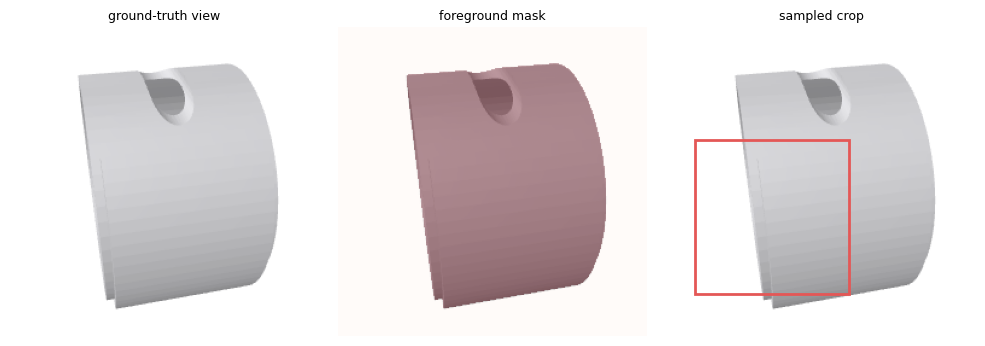

crop box (top, left, h, w): (93, 23, 128, 128)


In [7]:
# Where the loss looks: crop windows biased toward the object (most of a
# view is background, which teaches nothing).
demo_item = train_dataset[0]
crop_rng = np.random.default_rng(SEED)
box = data.sample_crop_box(demo_item["masks"][0], cfg.render_crop, crop_rng)
fig = viz.crop_debug_figure(demo_item["views"][0], demo_item["masks"][0], box)
plt.show()
print("crop box (top, left, h, w):", box)

In [ ]:
# Integration check: render that crop with the untrained model, next to
# the ground truth it will be compared against. A gray blob is EXPECTED
# here - nothing has been trained yet; this is the starting point.
with torch.no_grad():
    with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=device == "cuda"):
        demo_code = smodel.encode_sketches(model, demo_item["sketch"][None].to(device))[0]
    demo_code = demo_code.float()
    rays_o, rays_d = cameras.rays_for_crop(
        demo_item["c2ws"][0], FOVY_DEG, cfg.gt_size, box
    )
    rgb_fg, opacity = render_rays(model, demo_code, rays_o.to(device), rays_d.to(device))
print("rendered crop:", tuple(rgb_fg.shape), "  opacity:", tuple(opacity.shape))

top, left, h, w = box
gt_crop = demo_item["views"][0][top : top + h, left : left + w]
pred_crop = (rgb_fg + 0.5 * (1 - opacity[..., None])).clamp(0, 1).cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.4))
axes[0].imshow(gt_crop)
axes[0].set_title("ground-truth crop")
axes[1].imshow(pred_crop)
axes[1].set_title("untrained render (expected: gray ghost)")
for ax in axes:
    ax.axis("off")
plt.show()

In [ ]:
# The loss, in two spaces (both live in starx/train.py):
# 2D render space - pixel MSE + perceptual LPIPS on gray-composited crops,
# plus binary cross-entropy pulling rendered opacity toward the mask.
# 3D volume space - carve a visual hull from the sample's stored masks
# (a voxel outside any silhouette is provably empty; the intersection of
# all silhouette cones is a tight superset of the true solid) and pull
# predicted per-voxel occupancy toward it with a soft Dice loss.
print(inspect.getsource(strain.compute_render_loss))
print(inspect.getsource(strain.soft_dice_loss))

# the 2D terms on the untrained demo crop
gt_rgb = torch.from_numpy(np.ascontiguousarray(gt_crop)).float().to(device) / 255.0
gt_mask = torch.from_numpy(
    np.ascontiguousarray(demo_item["masks"][0][top : top + h, left : left + w])
).to(device)
loss, parts = strain.compute_render_loss(
    rgb_fg, opacity, gt_rgb, gt_mask, lpips_metric, cfg
)
print(f"untrained 2D loss: {float(loss):.3f}   terms: {parts}")

# the 3D target for this design: its visual hull, shown as a mid slice
hull, observed = strain.visual_hull_grid(
    demo_item["masks"], demo_item["c2ws"], cfg.hull_res, cfg.gt_size, device
)
hull_3d = hull.reshape(cfg.hull_res, cfg.hull_res, cfg.hull_res).cpu().numpy()
fig, ax = plt.subplots(figsize=(3.8, 3.8))
ax.imshow(hull_3d[:, :, cfg.hull_res // 2].T, cmap="gray", origin="lower")
ax.set_title("visual hull of the demo design, mid-height slice", fontsize=10)
ax.axis("off")
plt.show()
print(f"observed voxels: {float(observed.float().mean()):.1%}   "
      f"hull fills {float(hull[observed].float().mean()):.1%} of them")

In [ ]:
# One optimizer step - the full implementation is starx.train.train_step:
# the two-stage backward, the 3D hull term, fp16 gradient scaling with
# skip-on-overflow, and the cross-rank gradient reduction the multi-GPU
# script uses. Bound here to this session's pieces; every random choice
# inside is seeded by the step number, which is what makes resuming exact.
def train_step(step):
    return strain.train_step(
        step, model, train_dataset, optimizer, scheduler, trainable_params,
        lpips_metric, cfg, device, AMP_DTYPE, GRAD_SCALE,
    )


print("train_step bound - the loop below times its first call")

## Surviving disconnects

Colab sessions end - idle timeouts, usage caps, browser crashes. The run treats that as normal:

- every checkpoint interval, the trainable tensors (a few dozen MB, not the 1.7 GB model), optimizer state, schedule, and all random-number states are written to Drive atomically (temp file, then rename - a mid-write disconnect can never corrupt the newest checkpoint), keeping only the last few;
- the step number seeds every random choice (which designs, which views, which crops), so a resumed run draws exactly what an uninterrupted run would have drawn - no dataloader state to save;
- logs are append-only, so the loss curve just continues.

Killing the loop and re-running the notebook with the same run name is the officially supported way to train for longer than one session.

## Scaling to multiple GPUs

The loop below uses one GPU. When this Jupyter session sits on a node with several (for example 2x A100 through a VS Code tunnel), use all of them via the script that shares this exact training core (`starx/train.py`): the next cell launches it as a subprocess on every visible GPU, with this notebook's own configuration.

How it parallelizes: each GPU builds an identical model replica, handles an interleaved slice of every step's designs, and gradients are summed across ranks before an identical update on every rank - the same effective batch, finished N times faster. With 2 GPUs the default 8-design step splits 4/4; raising `accum_designs` to 16 doubles the effective batch at roughly the single-GPU step time.

Checkpoints, logs, and validation grids use the same run-directory format as this notebook, so the analysis cells below read script-trained runs unchanged, and the same run name resumes across notebook and script freely.

For a long run, prefer pasting the printed command into a VS Code terminal inside `tmux` - a subprocess launched from a cell dies with the kernel, and the resumable checkpoints make that survivable but wasteful.

In [ ]:
# Multi-GPU launcher: runs the shared training core on every visible GPU
# of this node, with this notebook's configuration. It first releases the
# kernel's own copy of the model so the ranks get all the GPU memory
# (re-run the model cell above afterwards for the analysis section).
# Skip this cell entirely for single-GPU training - just run the loop below.
N_GPUS = torch.cuda.device_count()

try:
    del model
    torch.cuda.empty_cache()
    print("released the kernel's model to free GPU memory for the ranks")
except NameError:
    pass

launch = [
    sys.executable, "-m", "torch.distributed.run",
    "--standalone", f"--nproc_per_node={N_GPUS}",
    str(Path(REPO_DIR) / "scripts" / "train.py"),
    "--data-root", cfg.drive_root,
    "--run-name", RUN_NAME,
    "--total-steps", str(cfg.total_steps),
    "--accum-designs", str(cfg.accum_designs),
    "--lambda-occ", str(cfg.lambda_occ),
    "--lr", str(cfg.lr),
    "--triposr-dir", TRIPOSR_DIR,
]
if SMOKE:
    launch.append("--smoke")

print(f"launching on {N_GPUS} GPU(s) - the same command works in a tmux terminal:\n")
print(" ".join(launch), "\n")
subprocess.run(launch, check=False)

In [11]:
# Resume: restore the newest checkpoint for this run name - model,
# optimizer, schedule, and random state - or start fresh.
rdir = run_dir(cfg, RUN_NAME)
latest = checkpoint.find_latest(rdir) if RESUME else None
if latest is not None:
    ckpt_path, start_step = latest
    state = checkpoint.load_checkpoint(ckpt_path)
    smodel.load_trainable_state_dict(model, state["model"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    checkpoint.restore_rng(state["rng"])
    print(f"resumed {RUN_NAME} at step {start_step}")
else:
    start_step = 0
    print(f"starting {RUN_NAME} fresh")

starting baseline_l4 fresh


In [ ]:
# The loop. Everything before was preparation; this cell can run for hours
# and can be killed and re-run at any time - it resumes automatically.
# A validation grid renders right after the first step of every session
# (so you always see the current state), then every interval after; the
# first step also prints its time and the VRAM peak so a speed or memory
# problem surfaces in seconds, not hours.
log_path = rdir / "logs" / "train_log.jsonl"
grid_dir = rdir / "val_grids"
grid_dir.mkdir(parents=True, exist_ok=True)
val_items = [val_dataset[i] for i in range(min(4, len(val_dataset)))]


def render_val_grid(items, step):
    """Sketch | ground truth | current prediction, one row per design."""
    model.eval()
    model.renderer.set_chunk_size(cfg.eval_chunk)
    fig, axes = plt.subplots(len(items), 3, figsize=(9.6, 3.1 * len(items)))
    axes = np.atleast_2d(axes)
    with torch.no_grad():
        for row, item in enumerate(items):
            with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=device == "cuda"):
                code = smodel.encode_sketches(model, item["sketch"][None].to(device))[0]
            code = code.float()
            rays_o, rays_d = cameras.rays_full(item["c2ws"][0], FOVY_DEG, cfg.gt_size)
            rgb_fg, opacity = render_rays(model, code, rays_o.to(device), rays_d.to(device))
            pred = composite_over_gray(rgb_fg, opacity).clamp(0, 1).cpu().numpy()
            gt = item["views"][0].astype(np.float32) / 255.0
            gt = np.where(item["masks"][0][..., None], gt, 0.5)
            axes[row, 0].imshow(item["stack_uint8"][0], cmap="gray", vmin=0, vmax=255)
            axes[row, 1].imshow(gt)
            axes[row, 2].imshow(pred)
            axes[row, 0].set_ylabel(item["design_id"][:12], fontsize=8)
    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0, 0].set_title("first sketch")
    axes[0, 1].set_title("ground truth")
    axes[0, 2].set_title(f"prediction @ step {step}")
    model.renderer.set_chunk_size(0)
    model.train()
    return fig


progress = tqdm(range(start_step, cfg.total_steps), initial=start_step, total=cfg.total_steps)
for step in progress:
    step_started = time.time()
    totals = train_step(step)
    if step == start_step:
        print(f"first step: {time.time() - step_started:.1f}s")
        if device == "cuda":
            print(f"peak VRAM: {torch.cuda.max_memory_allocated() / 2**30:.1f} GiB")
    progress.set_postfix(loss=f"{totals['loss']:.3f}")
    completed = step + 1
    if completed % 50 == 0 or completed == cfg.total_steps:
        checkpoint.append_log(log_path, {"step": completed, **totals})
    if completed % cfg.ckpt_every == 0 or completed == cfg.total_steps:
        checkpoint.save_checkpoint(
            rdir,
            completed,
            {
                "model": smodel.trainable_state_dict(model),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "rng": checkpoint.rng_states(),
            },
            keep_k=cfg.keep_k,
        )
    if (
        completed % cfg.val_every == 0
        or completed == cfg.total_steps
        or completed == start_step + 1
    ):
        fig = render_val_grid(val_items, completed)
        fig.savefig(grid_dir / f"step_{completed:07d}.png", dpi=110, bbox_inches="tight")
        plt.show()
print("training loop finished")

In [ ]:
# The full training history: loss terms (log scale) and the LR schedule.
history = checkpoint.read_log(log_path)
fig = viz.plot_loss_curves(history, keys=("loss", "mse", "lpips", "mask", "occ"))
plt.show()

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(history["step"], history["lr"], color=plt.get_cmap("tab10").colors[4])
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
ax.grid(alpha=0.3)
plt.show()

In [ ]:
# Post-run gallery on more designs than the loop's four.
gallery_items = [val_dataset[i] for i in range(min(6, len(val_dataset)))]
latest_step = checkpoint.find_latest(rdir)[1]
fig = render_val_grid(gallery_items, latest_step)
plt.show()

In [ ]:
# Before and after: the loop saved a validation grid every interval - the
# first and the last tell the story of the run.
from PIL import Image

grids = sorted(grid_dir.glob("step_*.png"))
if len(grids) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
    for ax, path in zip(axes, [grids[0], grids[-1]]):
        ax.imshow(Image.open(path))
        ax.set_title(path.stem)
        ax.axis("off")
    plt.show()
else:
    print(f"{len(grids)} grid(s) saved so far - train longer to compare")

In [ ]:
# Post-mortem probe: does the prediction depend on the input at all?
# Render three different designs and an all-blank stack through the
# current checkpoint, from the same camera. If all four look identical,
# the model ignores its input (mean-shape collapse). If they differ but
# are all shapeless clouds, it is hedging - typically orientation
# ambiguity between pose-free sketches and mesh-frame supervision.
import itertools

from starx.config import CAMERA_DISTANCE

probe_items = [val_dataset[i] for i in range(min(3, len(val_dataset)))]
inputs = [item["sketch"] for item in probe_items]
inputs.append(torch.full_like(inputs[0], cfg.bg_value / 255.0))
labels = [item["design_id"][:10] for item in probe_items] + ["all blank"]

model.eval()
model.renderer.set_chunk_size(cfg.eval_chunk)
probe_c2w = cameras.build_spherical_c2w(30.0, 20.0, CAMERA_DISTANCE)
preds = []
with torch.no_grad():
    for sk in inputs:
        with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=device == "cuda"):
            code = smodel.encode_sketches(model, sk[None].to(device))[0]
        code = code.float()
        rays_o, rays_d = cameras.rays_full(probe_c2w, FOVY_DEG, cfg.gt_size)
        rgb_fg, opacity = render_rays(model, code, rays_o.to(device), rays_d.to(device))
        preds.append(composite_over_gray(rgb_fg, opacity).clamp(0, 1).cpu().numpy())
model.renderer.set_chunk_size(0)

fig, axes = plt.subplots(1, len(preds), figsize=(3.1 * len(preds), 3.5))
for ax, pred, label in zip(axes, preds, labels):
    ax.imshow(pred)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.show()

design_diffs = [np.abs(a - b).mean() for a, b in itertools.combinations(preds[:-1], 2)]
blank_diffs = [np.abs(p - preds[-1]).mean() for p in preds[:-1]]
print(f"mean |pred_i - pred_j| across designs: {np.mean(design_diffs):.4f}")
print(f"mean |pred_i - blank|:                 {np.mean(blank_diffs):.4f}")
print("near zero on both lines = the model ignores its input entirely")

## Reading the results

The validation grids are the honest signal: predictions should sharpen from gray blobs toward the ground-truth silhouettes as steps accumulate, and the loss terms should fall together (if LPIPS stalls while MSE falls, the model is matching pixels but not structure).

Notebook 06 measures this properly - 3D metrics against ground-truth meshes on the held-out test split, plus a comparison against the pretrained model given the dataset's own thumbnails.